<a href="https://colab.research.google.com/github/Komali-devireddy/Telangana-District-Map-Coloring-Using-AC-3/blob/main/Telangana_District_Map_Coloring_Using_AC_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Telangana District Map Coloring Using AC-3



##Install/import libraries

In [1]:
# Install required libraries
!pip -q install geopandas matplotlib requests shapely

import geopandas as gpd
import matplotlib.pyplot as plt
import requests
import json
import random
from collections import deque

##Define all 33 Telangana districts

In [2]:
districts = [
    "Adilabad",
    "Bhadradri Kothagudem",
    "Hanumakonda",
    "Hyderabad",
    "Jagtial",
    "Jangaon",
    "Jayashankar Bhupalpally",
    "Jogulamba Gadwal",
    "Kamareddy",
    "Karimnagar",
    "Khammam",
    "Kumuram Bheem",
    "Mahabubabad",
    "Mahabubnagar",
    "Mancherial",
    "Medak",
    "Medchal-Malkajgiri",
    "Mulugu",
    "Nagarkurnool",
    "Nalgonda",
    "Narayanpet",
    "Nirmal",
    "Nizamabad",
    "Peddapalli",
    "Rajanna Sircilla",
    "Rangareddy",
    "Sangareddy",
    "Siddipet",
    "Suryapet",
    "Vikarabad",
    "Wanaparthy",
    "Warangal",
    "Yadadri Bhuvanagiri"
]

print("Total districts:", len(districts))

Total districts: 33


##Telangana 33 districts adjacency graph

In [4]:
# ============================================
# TELANGANA 33 DISTRICTS - ADJACENCY GRAPH
# ============================================

districts = [
    "Adilabad",
    "Bhadradri Kothagudem",
    "Hanumakonda",
    "Hyderabad",
    "Jagtial",
    "Jangaon",
    "Jayashankar Bhupalpally",
    "Jogulamba Gadwal",
    "Kamareddy",
    "Karimnagar",
    "Khammam",
    "Kumuram Bheem",
    "Mahabubabad",
    "Mahabubnagar",
    "Mancherial",
    "Medak",
    "Medchal-Malkajgiri",
    "Mulugu",
    "Nagarkurnool",
    "Nalgonda",
    "Narayanpet",
    "Nirmal",
    "Nizamabad",
    "Peddapalli",
    "Rajanna Sircilla",
    "Rangareddy",
    "Sangareddy",
    "Siddipet",
    "Suryapet",
    "Vikarabad",
    "Wanaparthy",
    "Warangal",
    "Yadadri Bhuvanagiri"
]

print("Total districts:", len(districts))

Total districts: 33


##Create the district adjacency relationships

In [6]:
# ============================================
# ADJACENCY LIST
# ============================================

adjacency = {

    "Adilabad": {
        "Kumuram Bheem",
        "Nirmal"
    },

    "Bhadradri Kothagudem": {
        "Khammam",
        "Mahabubabad",
        "Mulugu"
    },

    "Hanumakonda": {
        "Jangaon",
        "Jayashankar Bhupalpally",
        "Mulugu",
        "Warangal"
    },

    "Hyderabad": {
        "Medchal-Malkajgiri",
        "Rangareddy"
    },

    "Jagtial": {
        "Karimnagar",
        "Nirmal",
        "Peddapalli",
        "Rajanna Sircilla"
    },

    "Jangaon": {
        "Hanumakonda",
        "Mahabubabad",
        "Siddipet",
        "Suryapet",
        "Warangal",
        "Yadadri Bhuvanagiri"
    },

    "Jayashankar Bhupalpally": {
        "Bhadradri Kothagudem",
        "Hanumakonda",
        "Mahabubabad",
        "Mulugu",
        "Peddapalli"
    },

    "Jogulamba Gadwal": {
        "Mahabubnagar",
        "Nagarkurnool",
        "Wanaparthy"
    },

    "Kamareddy": {
        "Medak",
        "Nizamabad",
        "Sangareddy",
        "Siddipet"
    },

    "Karimnagar": {
        "Jagtial",
        "Peddapalli",
        "Rajanna Sircilla",
        "Siddipet"
    },

    "Khammam": {
        "Bhadradri Kothagudem",
        "Mahabubabad",
        "Suryapet"
    },

    "Kumuram Bheem": {
        "Adilabad",
        "Mancherial",
        "Nirmal"
    },

    "Mahabubabad": {
        "Bhadradri Kothagudem",
        "Jangaon",
        "Jayashankar Bhupalpally",
        "Khammam",
        "Mulugu",
        "Warangal"
    },

    "Mahabubnagar": {
        "Jogulamba Gadwal",
        "Narayanpet",
        "Nagarkurnool",
        "Wanaparthy"
    },

    "Mancherial": {
        "Kumuram Bheem",
        "Nirmal",
        "Peddapalli"
    },

    "Medak": {
        "Kamareddy",
        "Sangareddy",
        "Siddipet"
    },

    "Medchal-Malkajgiri": {
        "Hyderabad",
        "Medak",
        "Sangareddy",
        "Siddipet",
        "Yadadri Bhuvanagiri"
    },

    "Mulugu": {
        "Bhadradri Kothagudem",
        "Hanumakonda",
        "Jayashankar Bhupalpally",
        "Mahabubabad",
        "Warangal"
    },

    "Nagarkurnool": {
        "Jogulamba Gadwal",
        "Mahabubnagar",
        "Nalgonda",
        "Wanaparthy"
    },

    "Nalgonda": {
        "Nagarkurnool",
        "Suryapet",
        "Yadadri Bhuvanagiri"
    },

    "Narayanpet": {
        "Mahabubnagar",
        "Vikarabad"
    },

    "Nirmal": {
        "Adilabad",
        "Jagtial",
        "Kumuram Bheem",
        "Mancherial",
        "Nizamabad"
    },

    "Nizamabad": {
        "Kamareddy",
        "Nirmal"
    },

    "Peddapalli": {
        "Jagtial",
        "Jayashankar Bhupalpally",
        "Karimnagar",
        "Mancherial",
        "Rajanna Sircilla"
    },

    "Rajanna Sircilla": {
        "Jagtial",
        "Karimnagar",
        "Peddapalli",
        "Siddipet"
    },

    "Rangareddy": {
        "Hyderabad",
        "Sangareddy",
        "Vikarabad",
        "Yadadri Bhuvanagiri"
    },

    "Sangareddy": {
        "Kamareddy",
        "Medak",
        "Medchal-Malkajgiri",
        "Rangareddy",
        "Vikarabad"
    },

    "Siddipet": {
        "Jangaon",
        "Kamareddy",
        "Karimnagar",
        "Medak",
        "Medchal-Malkajgiri",
        "Rajanna Sircilla",
        "Yadadri Bhuvanagiri"
    },

    "Suryapet": {
        "Jangaon",
        "Khammam",
        "Nalgonda",
        "Yadadri Bhuvanagiri"
    },

    "Vikarabad": {
        "Mahabubnagar",
        "Narayanpet",
        "Rangareddy",
        "Sangareddy"
    },

    "Wanaparthy": {
        "Jogulamba Gadwal",
        "Mahabubnagar",
        "Nagarkurnool"
    },

    "Warangal": {
        "Hanumakonda",
        "Jangaon",
        "Mahabubabad",
        "Mulugu"
    },

    "Yadadri Bhuvanagiri": {
        "Jangaon",
        "Medchal-Malkajgiri",
        "Nalgonda",
        "Rangareddy",
        "Siddipet",
        "Suryapet"
    }
}

print("Adjacency graph created.")

Adjacency graph created.


##AC-3 implementatio

In [7]:
from collections import deque

colors = ["Red", "Green", "Blue", "Yellow"]

domains = {
    district: colors.copy()
    for district in districts
}


def revise(domains, Xi, Xj):

    revised = False

    for x in domains[Xi].copy():

        # There must be at least one different
        # color available for the neighbour.
        if not any(x != y for y in domains[Xj]):
            domains[Xi].remove(x)
            revised = True

    return revised


def ac3(domains, adjacency):

    queue = deque()

    for Xi in adjacency:
        for Xj in adjacency[Xi]:
            queue.append((Xi, Xj))

    while queue:

        Xi, Xj = queue.popleft()

        if revise(domains, Xi, Xj):

            if len(domains[Xi]) == 0:
                return False

            for Xk in adjacency[Xi]:

                if Xk != Xj:
                    queue.append((Xk, Xi))

    return True

##Solve using AC-3 + backtracking

In [8]:
def is_consistent(district, color, assignment):

    for neighbour in adjacency[district]:

        if neighbour in assignment:

            if assignment[neighbour] == color:
                return False

    return True


def select_unassigned_variable(assignment, domains):

    unassigned = [
        d for d in districts
        if d not in assignment
    ]

    return min(
        unassigned,
        key=lambda d: len(domains[d])
    )


def backtracking_search(assignment, domains):

    # All 33 districts assigned
    if len(assignment) == len(districts):
        return assignment

    district = select_unassigned_variable(
        assignment,
        domains
    )

    for color in domains[district]:

        if is_consistent(
            district,
            color,
            assignment
        ):

            assignment[district] = color

            new_domains = {
                d: domains[d].copy()
                for d in domains
            }

            new_domains[district] = [color]

            # AC-3 propagation
            if ac3(new_domains, adjacency):

                result = backtracking_search(
                    assignment,
                    new_domains
                )

                if result is not None:
                    return result

            del assignment[district]

    return None

In [9]:
initial_domains = {
    district: colors.copy()
    for district in districts
}

if ac3(initial_domains, adjacency):

    solution = backtracking_search(
        {},
        initial_domains
    )

else:
    solution = None


if solution:
    print("🎉 SUCCESS!")
    print("All 33 Telangana districts have been colored.")
else:
    print("No solution found.")

🎉 SUCCESS!
All 33 Telangana districts have been colored.


##final result

In [10]:
print("\nTELANGANA DISTRICT COLORING")
print("=" * 45)

for district in sorted(solution):

    print(
        f"{district:30s} → {solution[district]}"
    )


TELANGANA DISTRICT COLORING
Adilabad                       → Red
Bhadradri Kothagudem           → Yellow
Hanumakonda                    → Red
Hyderabad                      → Red
Jagtial                        → Red
Jangaon                        → Green
Jayashankar Bhupalpally        → Green
Jogulamba Gadwal               → Green
Kamareddy                      → Green
Karimnagar                     → Green
Khammam                        → Green
Kumuram Bheem                  → Green
Mahabubabad                    → Red
Mahabubnagar                   → Yellow
Mancherial                     → Red
Medak                          → Blue
Medchal-Malkajgiri             → Green
Mulugu                         → Blue
Nagarkurnool                   → Red
Nalgonda                       → Green
Narayanpet                     → Red
Nirmal                         → Blue
Nizamabad                      → Red
Peddapalli                     → Blue
Rajanna Sircilla               → Yellow
Rangareddy     

##Verify that adjacent districts have different colors

In [11]:
valid = True

for district in adjacency:

    for neighbour in adjacency[district]:

        if solution[district] == solution[neighbour]:

            print(
                "❌ Conflict:",
                district,
                neighbour
            )

            valid = False

if valid:
    print("\n✅ VALID MAP COLORING")
    print("No adjacent districts have the same color.")


✅ VALID MAP COLORING
No adjacent districts have the same color.


##Create a visual district graph

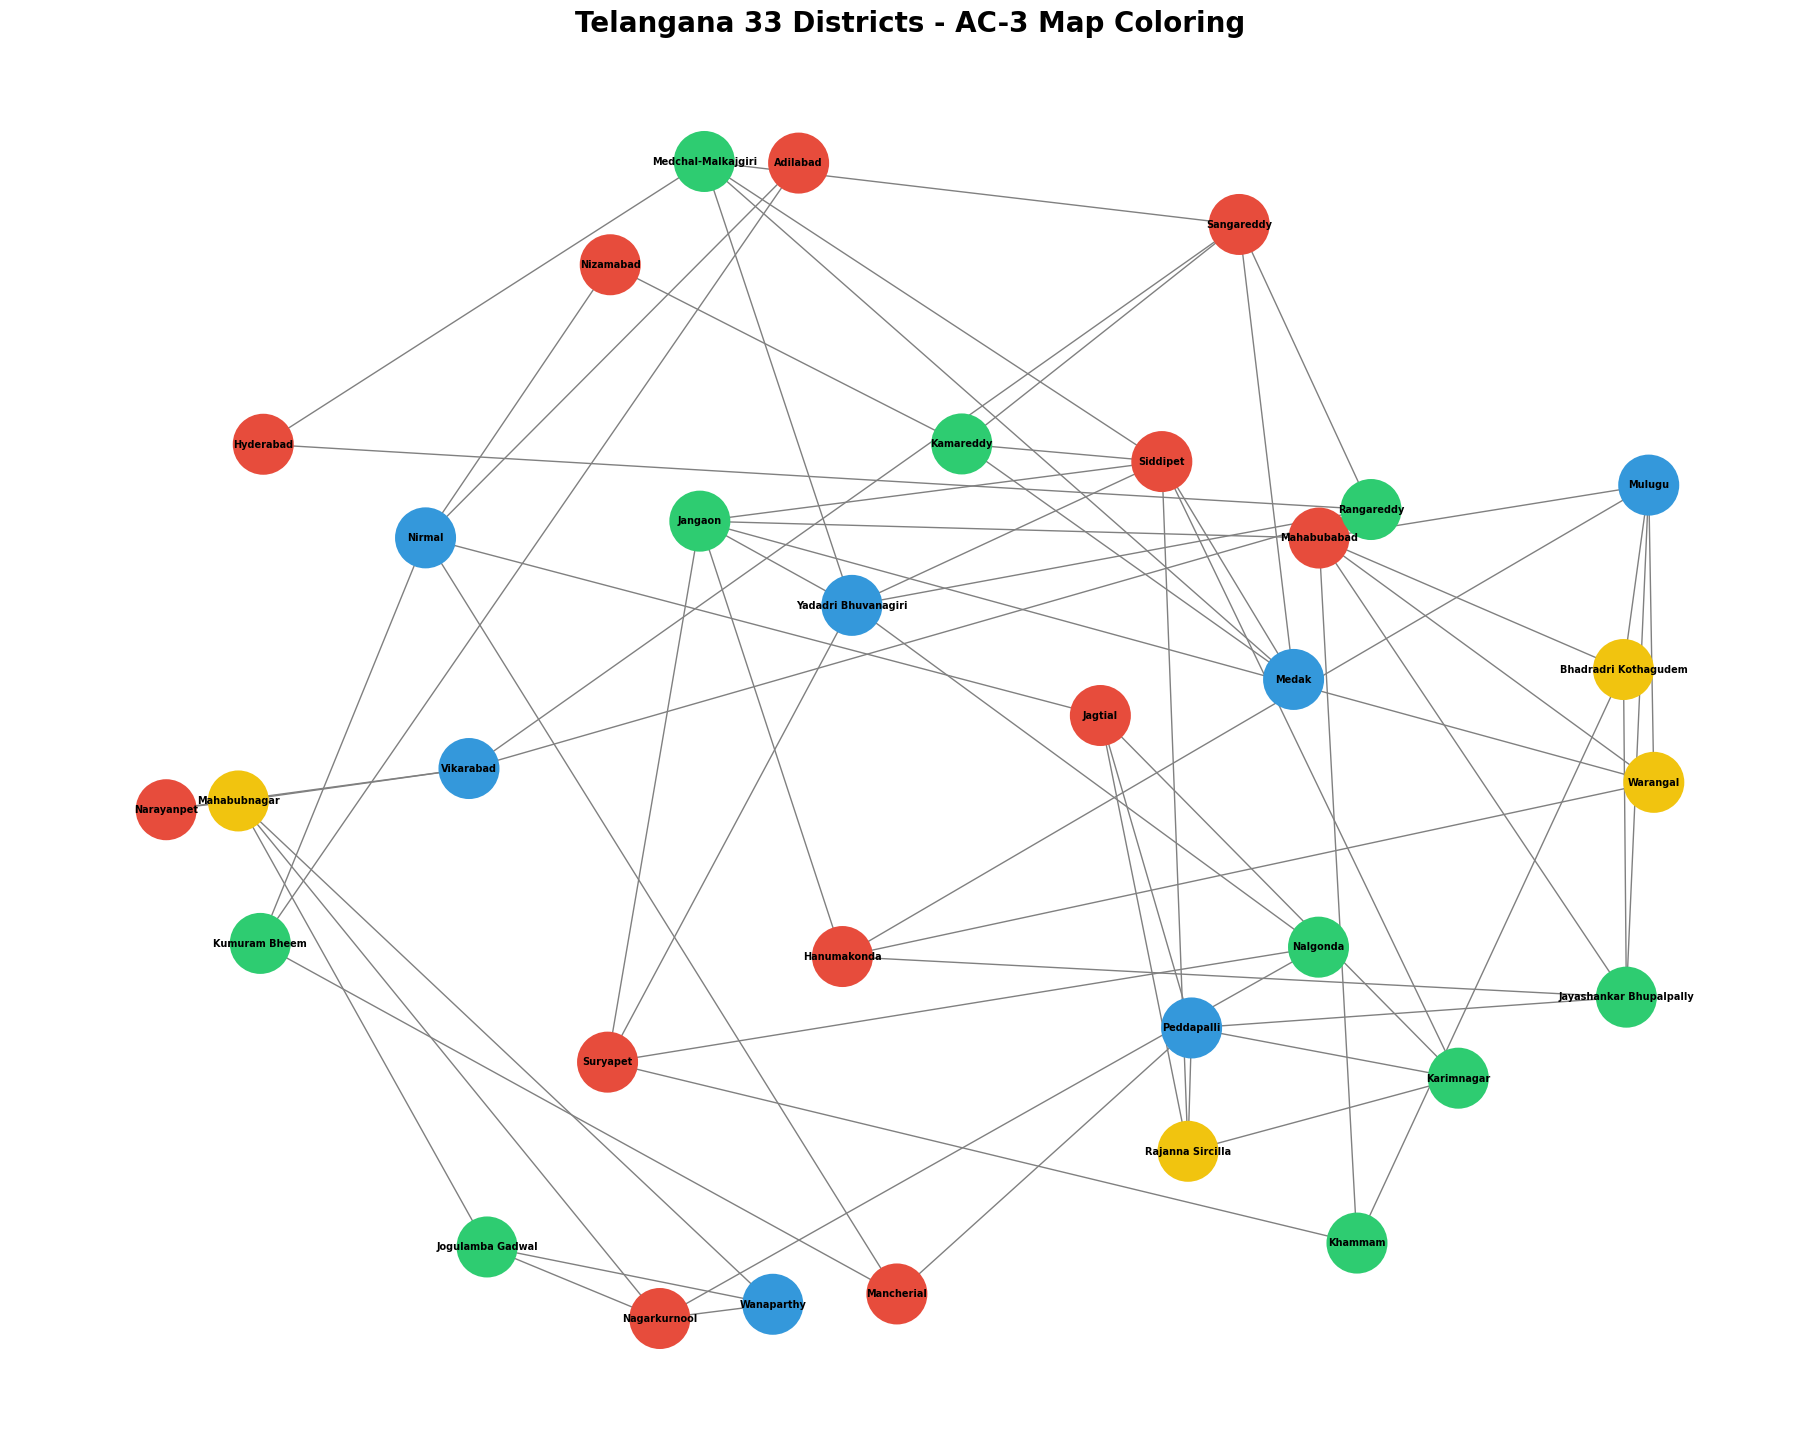

In [12]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

# Add districts
G.add_nodes_from(districts)

# Add adjacency edges
for district in adjacency:

    for neighbour in adjacency[district]:

        G.add_edge(district, neighbour)


# Color mapping
color_map = {
    "Red": "#e74c3c",
    "Green": "#2ecc71",
    "Blue": "#3498db",
    "Yellow": "#f1c40f"
}

node_colors = [
    color_map[solution[district]]
    for district in G.nodes()
]


plt.figure(figsize=(18, 14))

pos = nx.spring_layout(
    G,
    seed=42,
    k=1.5
)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=1800,
    font_size=7,
    font_weight="bold",
    edge_color="gray",
    linewidths=1.5
)

plt.title(
    "Telangana 33 Districts - AC-3 Map Coloring",
    fontsize=20,
    fontweight="bold"
)

plt.axis("off")
plt.show()